# Assignment 4 — CIFAR-10 ConvNet

**DATAX504** · Due end of Week 8

Build on **Chapter 8** (ConvNets, augmentation) and ideas from **Chapters 9–10** (interpretation). You design the stack; the goal is a working pipeline you can explain, not a copy of a tutorial.

## Tasks
1. Load CIFAR-10, normalise, create a train / validation split
2. Build a **data augmentation** pipeline used during training
3. Train a **ConvNet** that reaches **>65%** test accuracy
4. Visualise at least one filter / feature (layer weights or activation-based)
5. Brief interpretation of what that filter responds to (Moodle `a4_interpretation`)

## Moodle fields
`a4_repo`, `a4_test_acc`, `a4_filter_layer`, `a4_interpretation`

## AI disclosure (required)
Fill the table in the next cell before you submit.


## AI disclosure

| Field | Your answer                                                                                                                                              |
|-------|----------------------------------------------------------------------------------------------------------------------------------------------------------|
| Tool / model | Codex Gpt-5.5                                                                                                                                            |
| Used for | Code suggestions and explanations for the CIFAR-10 ConvNet pipeline, including preproces  augmentation, model design, training, and filter interpreation |
| Verified how |                                                  I executed the notebook, checked the dataset shapes, model summary, test accuracy, and filter visualisation output.                                                                                                        |
| Not used for |      Final submission without review; I checked and edited the generated code myself.                                                                                                                                                    |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import keras
from keras import layers


## 1. Load & prepare CIFAR-10

Hints:
- `keras.datasets.cifar10.load_data()`
- cast pixels to float and scale to `[0, 1]` (or another range you document)
- flatten label shape if needed (`y.ravel()`)
- hold out a validation slice from the training set (e.g. last 5_000 or 10_000)


In [3]:
# source .venv-tfmetal/bin/activate, converts to .venv‑tfmetal
# 10 classes with 0-9 index
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck",
]

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Convert image pixels from integers [0, 255] to floats [0, 1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

#CIFAR-10 labels load as shape (num_samples,1); sparse loss function expects (num_samples,)
y_train = y_train.ravel()
y_test = y_test.ravel()

# validation split from training data
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

print("train:", getattr(x_train, "shape", None), getattr(y_train, "shape", None))
print("val:  ", getattr(x_val, "shape", None), getattr(y_val, "shape", None))
print("test: ", getattr(x_test, "shape", None), getattr(y_test, "shape", None))


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2051s 12us/step
train: (45000, 32, 32, 3) (45000,)
val:   (5000, 32, 32, 3) (5000,)
test:  (10000, 32, 32, 3) (10000,)


## 2. Data augmentation

Build a small `keras.Sequential` of image layers (e.g. flip / rotation / zoom).
Apply it **inside** the model (or as a preprocessing layer) so training sees augmented batches.

Preview a few transforms on one training image to check it works.


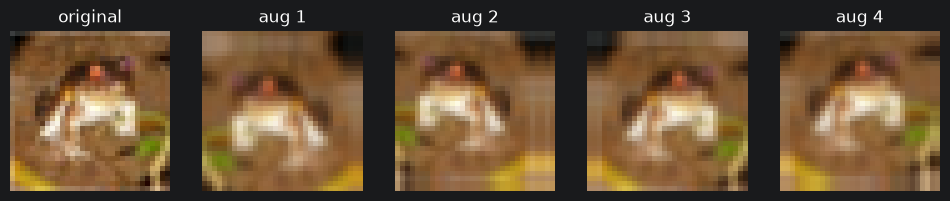

In [4]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.08),
        layers.RandomZoom(0.1),
        layers.RandomTranslation(0.1,0.1),
    ],
    name="augmentation",
)

# preview a few augmented versions of one training image
sample = x_train[0]
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes): #To draw a specific subgraph, you must use the ax function within the loop.
    if i == 0: #Execute only when the loop variable i equals 0 (i.e., during the first iteration).
        ax.imshow(sample)
        ax.set_title("original")
    else:
        augmented = data_augmentation(
            np.expand_dims(sample, axis=0), #TensorFlow/Keras models require a batch dimension in the input.
            training=True,
        )
        ax.imshow(np.squeeze(augmented,axis=0))
        ax.set_title(f"aug {i}")
    ax.axis("off")
plt.show()


## 3. ConvNet model

Requirements:
- Input shape `(32, 32, 3)`
- Include your augmentation as the first stage of the graph (training only behaviour is fine)
- At least two `Conv2D` + pooling stages, then a dense classifier for 10 classes
- Name at least one early conv layer (you will need the name for visualisation)

Compile with a suitable loss for integer class labels (or one-hot — be consistent).


In [7]:
inputs = keras.Input(shape=(32, 32, 3))

# Data augmentation is part of the model graph.
# It runs during training, but not during validation/testing
x = data_augmentation(inputs)

# Conv / pool / (optional BatchNorm, Dropout) stack
# Tip: name an early conv, e.g. name="conv2d_1"
x = layers.Conv2D(32, 3, padding="same", activation="relu", name="conv2d_1")(x)
x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(64, 3, padding="same", activation="relu", name="conv2d_2")(x)
x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Conv2D(128, 3, padding="same", activation="relu", name="conv2d_3")(x)
x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)

x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.4)(x)

# classifier head → 10-class output
outputs = layers.Dense(10, activation="softmax")(x)

model = keras.Model(inputs, outputs) # assign your Model here
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

print("Model ready:", model is not None)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 550,570 (2.10 MB)

 Trainable params: 550,570 (2.10 MB)

 Non-trainable params: 0 (0.00 B)

Model ready: True


## 4. Train & evaluate

Fit with `validation_data`. Aim for **>65%** test accuracy (Moodle wants the percentage).
Plot train vs val accuracy if useful for your write-up.


In [8]:
# fit
history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_data=(x_val, y_val),
    verbose=1,
)

# evaluate once on the test set
test_loss, test_acc = model.evaluate(x_test,y_test,verbose=0)

print(f"Test accuracy % (Moodle a4_test_acc): {100 * test_acc if test_acc is not None else None}")


Epoch 1/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.3096 - loss: 1.8567 - val_accuracy: 0.4574 - val_loss: 1.4969
Epoch 2/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.4546 - loss: 1.4993 - val_accuracy: 0.5150 - val_loss: 1.3490
Epoch 3/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.5203 - loss: 1.3386 - val_accuracy: 0.5552 - val_loss: 1.2862
Epoch 4/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - accuracy: 0.5665 - loss: 1.2304 - val_accuracy: 0.6200 - val_loss: 1.0951
Epoch 5/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 39ms/step - accuracy: 0.5969 - loss: 1.1467 - val_accuracy: 0.6076 - val_loss: 1.1528
Epoch 6/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.6179 - loss: 1.0956 - val_accuracy: 0.6868 - val_loss: 0.9289
Epoch 7/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.6384 - loss: 1.0444 - val_accuracy: 0.6820 - val_loss: 0.9187
Epoch 8/30
704/704 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.6538 - loss: 1.0024 - 

## 5. Filter visualisation

Pick a named conv layer (`a4_filter_layer`). Minimum expectation: plot first-layer filter weights as small images.

Optional deeper approach: gradient ascent / activation maximisation for one filter index (Ch 10 style).


Filter weights shape: (3, 3, 3, 32)
Bias shape: (32,)


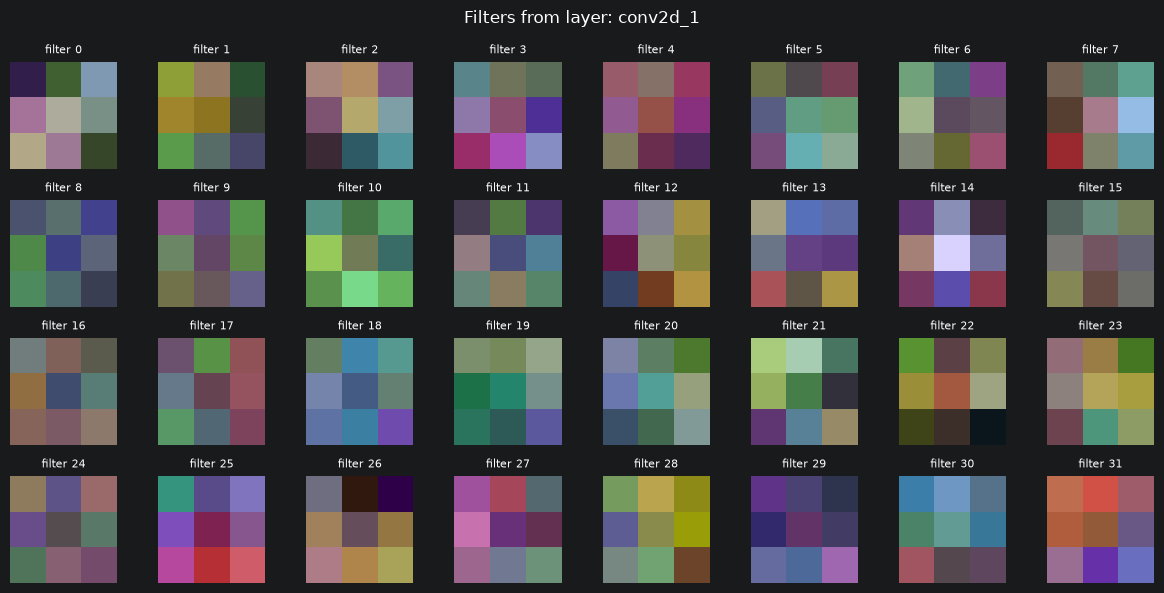

Visualisation layer (Moodle a4_filter_layer): conv2d_1


In [9]:
VIS_LAYER = "conv2d_1"  # match the name you set — Moodle a4_filter_layer

# get the layer, extract weights, plot a grid of filters
conv_layer = model.get_layer(VIS_LAYER)
filters, biases = conv_layer.get_weights()

print("Filter weights shape:", filters.shape)
print("Bias shape:", biases.shape)

# Normalize filters to [0, 1] so they can be displayed as images
f_min = filters.min()
f_max = filters.max()
filters_for_display = (filters - f_min) / (f_max - f_min)

num_filters = min(32, filters_for_display.shape[-1])
cols = 8
rows = int(np.ceil(num_filters / cols))

fig, axes = plt.subplots(rows, cols, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    if i < num_filters:
        # filters shape: (kernel_height, kernel_width, input_channels, output_channels)
        filter_img = filters_for_display[:, :, :, i]
        ax.imshow(filter_img)
        ax.set_title(f"filter {i}", fontsize=8)
    ax.axis("off")

plt.suptitle(f"Filters from layer: {VIS_LAYER}")
plt.tight_layout()
plt.show()

print(f"Visualisation layer (Moodle a4_filter_layer): {VIS_LAYER}")


## 6. Interpretation (Moodle `a4_interpretation`)

Max ~200 words: what pattern does your chosen filter respond to?


The filter 10 responds to local colour‑contrast patterns, particularly variations in green tones. Different positions across its RGB channels show clear differences. It will activate strongly when small patches in the input image contain distinct green‑based colour changes. It only learns a simple low‑level colour feature and cannot detect full objects on its own.

The filter 26 responds to local light‑dark edges. The top area of this kernel is much darker while the bottom is lighter. It gives a strong response where an image patch has sharp vertical brightness transitions. It extracts a basic low‑level edge feature.